In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import pandas as pd
import numpy as np
import geomodgen2d as gm

In [3]:
# Step 1: Unit Configuration

In [4]:
units_config = gm.Units() #Using default units config of "m"

In [5]:
# Step 2: Define Feature and Properties
x_span = 50
z_span = 30

In [6]:
from scipy.ndimage import gaussian_filter
import geomodgen2d.general_functions as f

def smooth_noise(shape, sigma=3, rng=np.random.default_rng()):
    noise = rng.random(shape) * 2 - 1  # random in [-1,1]
    noise_smooth = gaussian_filter(noise, sigma=sigma)
    # Normalize to [-1,1]
    noise_smooth = noise_smooth / np.max(np.abs(noise_smooth))
    return noise_smooth

class ManualObstruction2D(gm.Obstruction2D):
    def __init__(self, dl:float, ref_xz_symbolic = ['c', 'c'], snap_to_dl:bool=True):
        super().__init__(dl, ref_xz_symbolic, snap_to_dl)
       
    def karst_circle_perlin(self, d, noise_amplitude=0.1, smooth_sigma=3.0, obstruction_id=1, rng=np.random.default_rng()):
        assert self.shape is False, "ERROR: utils shape has already been defined"
        if d<0:
            raise ValueError("Diameter of the circle must be zero/positive")
        
        obstruction_id = f.check_obstruction_id(obstruction_id)

        d_adj = d
        r_nominal = d_adj / 2
        # Determine maximum radius including positive noise
        r_max = r_nominal * (1 + noise_amplitude)
        n_grid = int(np.ceil(2 * r_max / self.dl))
        
        grid = np.zeros((n_grid, n_grid), dtype=int)
        
        x = np.arange(n_grid) * self.dl + self.dl/2
        z = np.arange(n_grid) * self.dl + self.dl/2
        xx, zz = np.meshgrid(x, z, indexing='ij')
        
        # Generate smooth noise
        noise_smooth = smooth_noise((n_grid, n_grid), sigma=smooth_sigma, rng=rng)

        # Compute noisy radius
        r_grid = r_nominal * (1 + noise_amplitude * noise_smooth)

        # Compute distance from center
        center = r_max
        dist2 = (xx - center)**2 + (zz - center)**2
        grid[dist2 <= r_grid**2] = obstruction_id

        # Update object attributes
        self.grid2d = grid
        self.description = f'Karst circle (smooth noise) 2D, base diameter {d:.6g}'
        self.shape = True
        self.center_in_unit_length = [center, center]

In [7]:
rng = np.random.default_rng(seed=42)

soil_materials_distribution = gm.random_generators.Constant(val = 'soil', rng=rng)
utils_materials_distribution = gm.random_generators.Constant(val = 'PVC', rng=rng)
karst_materials_distribution = gm.random_generators.Constant(val = 'void', rng=rng)

feature_config_instance =  gm.FeaturesConfig()
feature_config_instance.add_feature('def', soil_materials_distribution, 'soil')
feature_config_instance.add_feature('U', utils_materials_distribution, 'utils')
feature_config_instance.add_feature('K', karst_materials_distribution, 'karst')

main_properties_config_instance =  gm.MainPropertiesConfig(feature_config_instance, layer0_flag=True)

main_properties_info = {'vs': {'desc':'shear wave velocity',
                               'layer0': [10,None]},
                       }

# vs property:
main_property_name = 'vs'
main_props_vals = main_properties_info[main_property_name]

#Define MainProperty instance
main_property_instance = gm.MainProperty(main_property_name, feature_config_instance, layer0_flag=True, description=main_props_vals['desc'])

# Define wet and dry properties for SOIL
wet_mean_distribution = gm.random_generators.Uniform(80, 900, rng)  
cov_distribution = gm.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='soil', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=None)


# Add layer0 val
wet_mean_distribution = gm.random_generators.Constant(10, rng)  
dry_mean_distribution = None
cov_distribution = None
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='layer0', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=None)



# For utils

# Add PVC val
wet_mean_distribution = gm.random_generators.Uniform(1140, 1750, rng)  
dry_mean_distribution = None
cov_distribution = None
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='U', material_name='PVC', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=None)


# For karst

# Add Void (material type for Karst)
wet_mean_distribution = gm.random_generators.Constant(10, rng)  
dry_mean_distribution = None
cov_distribution = None
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='K', material_name='void', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=None)


# Add MainProperty to MainPropertiesConfig instance
main_properties_config_instance.add_main_property(main_property_instance)


# Define some additional Properties
aux_props = gm.AuxillaryProperties()
aux_props.add_aux_property('n_layers',  gm.random_generators.DiscreteChoice(x=[3,4,5,6,7,8,9,10,11,12], p=[0.05,0.08,0.1,0.1,0.1,0.1,0.1,0.1,0.12,0.15], rng=rng))
aux_props.add_aux_property('rock_vs_mean',  gm.random_generators.Uniform(1200, 2500, rng))
aux_props.add_aux_property('gwt', gm.random_generators.Uniform(0, 30, rng))



utilities_sett={
    'n_obs': gm.random_generators.DiscreteChoice([0,1,2,3,4,5,6,7], rng=rng),
    'obs_shape': gm.random_generators.DiscreteChoice(['circ2d', 'rect2d',], [1/2, 1/2], rng=rng),
    'dia_obs':gm.random_generators.Uniform(1, 3, rng=rng), 
    'lh_obs':gm.random_generators.Uniform(1, 3, rng=rng), 
    'obs_x_coord':gm.random_generators.Uniform(0, x_span, rng=rng), 
    'depth_top_dist':gm.random_generators.Discrete2ContinuousPDF([0,5], p = [1,.2], new_del_x = 1, rng=rng), #Continuous distribution: discrete to be converted into continuous: also
}

karst_sett={
    'n_karst': gm.random_generators.DiscreteChoice([0,1,2], rng=rng),
    'karst_size':gm.random_generators.Uniform(2, 7, rng=rng), 
    'karst_x_coord':gm.random_generators.Uniform(0, x_span, rng=rng), 
    'karst_depth_top_dist':gm.random_generators.Discrete2ContinuousPDF([5,30], p = [.4,1], new_del_x = 1, rng=rng), #Continuous distribution: discrete to be converted into continuous: also
}

aux_props.add_aux_property('n_obs', utilities_sett['n_obs'])
aux_props.add_aux_property('obs_shape', utilities_sett['obs_shape'])
aux_props.add_aux_property('dia_obs', utilities_sett['dia_obs'])
aux_props.add_aux_property('lh_obs', utilities_sett['lh_obs'])
aux_props.add_aux_property('obs_x_coord', utilities_sett['obs_x_coord'])
aux_props.add_aux_property('depth_top_utils', utilities_sett['depth_top_dist'])


aux_props.add_aux_property('n_karst', karst_sett['n_karst'])
aux_props.add_aux_property('karst_size', karst_sett['karst_size'])
aux_props.add_aux_property('karst_x_coord', karst_sett['karst_x_coord'])
aux_props.add_aux_property('karst_depth_top_dist', karst_sett['karst_depth_top_dist'])
aux_props.print()


main_properties_config_instance.print()
print("")
aux_props.print()

Additional_Properties: dict_keys(['n_layers', 'rock_vs_mean', 'gwt', 'n_obs', 'obs_shape', 'dia_obs', 'lh_obs', 'obs_x_coord', 'depth_top_utils', 'n_karst', 'karst_size', 'karst_x_coord', 'karst_depth_top_dist'])
Main_Properties: ['vs']
feature_ids: ['def', 'U', 'K']
---------------------------
Property Name: vs
Description: shear wave velocity
All Feature IDs: ['def', 'U', 'K']
Properties:
{'def': {'soil': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001A49C102F70>},
         'layer0': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001A49C1033D0>}},
 'U': {'PVC': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001A49C1032E0>}},
 'K': {'void': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001A49C103380>}}}

Additional_Properties: dict_keys(['n_layers', 'rock_vs_mean', 'gwt', 'n_obs', 'obs_shape', 'dia_obs', 'lh_obs', 'obs_x_coord', 'depth_top_utils', 'n_karst', 'kar

In [8]:
# Step 2: Model Settings

In [9]:


del_xz_final = 1  #refining del_z for utilities generation
del_xz_obs = del_xz_final/10
remesh_interp_method = 'linear'
spatial_theta_x = 100
spatial_theta_z = 0.5

interface_sett= {
    'generate_surface':True,
    'rough_interface_creator_instance':gm.rough_interface_creator2d.UniformInterfaceGen(1, rng=rng),
    'rough_interface_generator_scale': [1.5,1.3,1.2,1], # If n_soil_layers>len(this list) uses last value for those layers.
    'interfaces_depths_generation':'random', 
    'interfaces_depth_reference_point_x':None,
    'filter_settings': {
                 'filter_window_length':21, #21 #must be odd
                 'filter_polyorder':7,
                        },
    'processing_settings': {
                'simulate_erosion': True,
            }
    }


n_layers = aux_props.aux_properties['n_layers'].generate()
gwt_depth = aux_props.aux_properties['gwt'].generate()


In [10]:
# Step 2.1 Domain Creation
domain_final   = gm.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, units_config)

<Axes: xlabel='Distance', ylabel='Depth'>

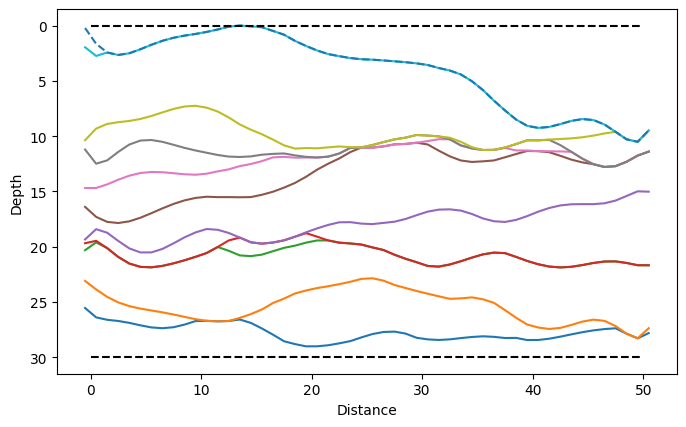

In [11]:
soil_interface = gm.DiscretizedInterfaces2DFromDict(domain_final, n_layers, interface_sett, remesh_interp_method=remesh_interp_method, rng=rng)
soil_interface.plot()

Ran auto test: Check
Ran auto test: Check
Ran auto test: Check


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\discretized_interfaces2d.py:507: UserWarning: Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.
  warnings.warn("Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.")


'from_interface_config'

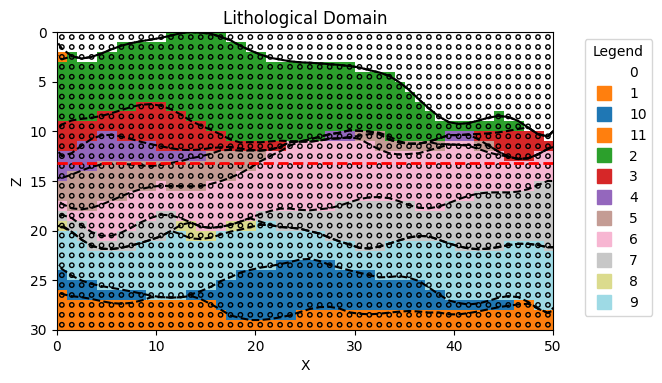

In [12]:
global_soil_interface_config = gm.GlobalSoilInterfaceConfig
global_soil_interface_config.reset()
global_soil_interface_config.set_soil_interface(soil_interface)

name = 'asdf'
lit = gm.LithologicalDomain2D(domain_final, gwt_depth, 'soil_lit')
lit.plot(discrete_point_size = 10, plot_interfaces=True)
lit.lm_type

Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\discretized_interfaces2d.py:69: UserWarning: rough_interface_generator_scale is [0] and hence only horizontal interfaces will be created if not corrected.
  warnings.warn("rough_interface_generator_scale is [0] and hence only horizontal interfaces will be created if not corrected.")


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

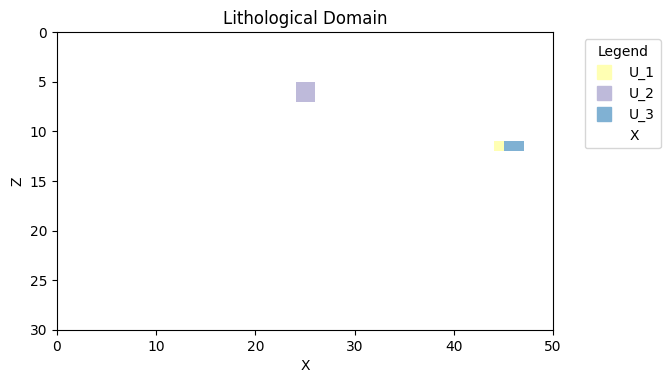

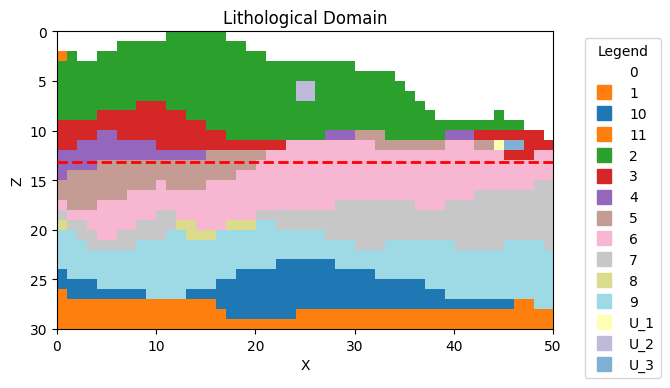

In [13]:
import matplotlib.pyplot as plt

n_obs = 3; #aux_props.aux_properties['n_obs'].generate()
obs_shapes = aux_props.aux_properties['obs_shape'].generate((n_obs,))
obs_lit = gm.LithologicalDomain2DFromObstruction2D(domain_final, 'obstructions')
for i, obs_shape in enumerate(obs_shapes):
    obs_x_coord = aux_props.aux_properties['obs_x_coord'].generate()
    d_obs = aux_props.aux_properties['depth_top_utils'].generate()
    obs_id = i+1
    obs_instance = gm.Obstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)
    if obs_shape == 'circ2d':
        d = aux_props.aux_properties['dia_obs'].generate()
        obs_instance.circle_2d(d, obstruction_id = obs_id)
    elif obs_shape == 'rect2d':
        lx = aux_props.aux_properties['lh_obs'].generate()
        lz = aux_props.aux_properties['lh_obs'].generate()
        obs_instance.rectangle_2d(lx, lz, obstruction_id = obs_id)
    else:
        raise ValueError(f"Invalid util_shape {obs_shape}")
    # obs_instance.plot()
    obs_lit.add_obstruction2D(obs_instance, shift_ref2d_to_xy = [obs_x_coord, d_obs], added_prefix='U')

obs_lit.plot()
merged_lit = lit.return_merged_lithological_domain([obs_lit])
merged_lit.plot()


Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

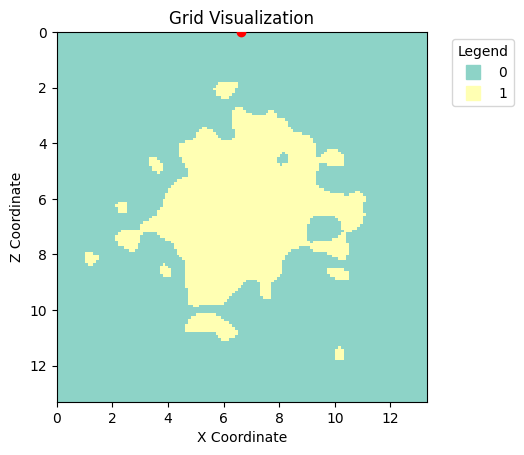

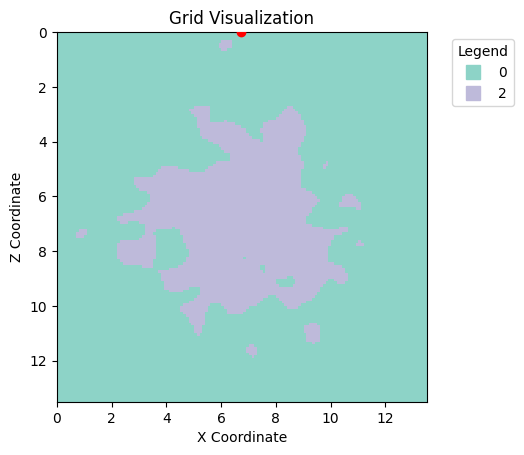

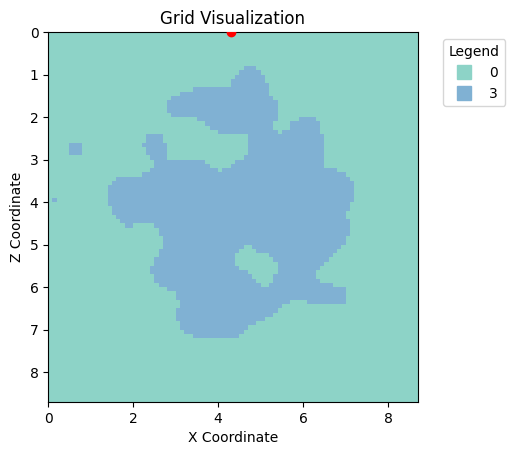

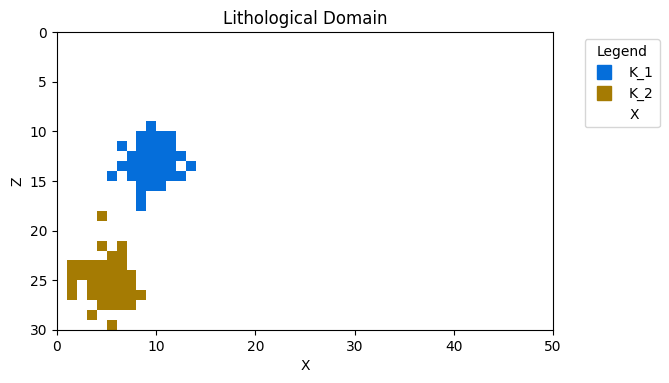

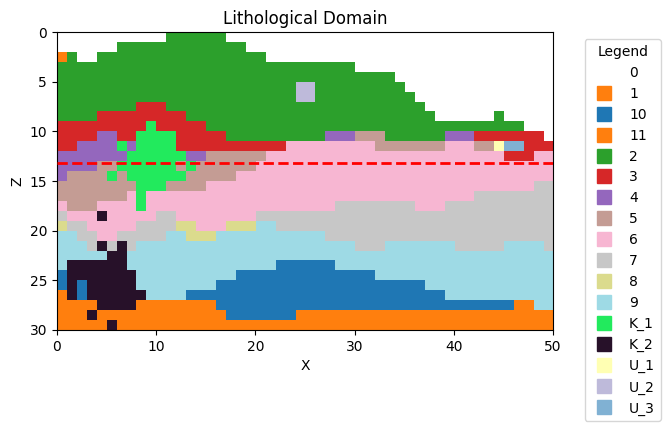

In [14]:
import matplotlib.pyplot as plt

n_karst = 3; #aux_props.aux_properties['n_karst'].generate()
karst_lit = gm.LithologicalDomain2DFromObstruction2D(domain_final, 'karst')
for i in range(n_karst):
    karst_x_coord = aux_props.aux_properties['karst_x_coord'].generate()
    d_obs = aux_props.aux_properties['karst_depth_top_dist'].generate()
    obs_id = i+1
    karst_instance = ManualObstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)
    d = aux_props.aux_properties['karst_size'].generate()
    karst_instance.karst_circle_perlin(d, noise_amplitude=1., smooth_sigma=3.0, obstruction_id=obs_id, rng=rng)
    karst_instance.plot()
    karst_lit.add_obstruction2D(karst_instance, shift_ref2d_to_xy = [karst_x_coord, d_obs], added_prefix='K')

karst_lit.plot()
merged_lit = lit.return_merged_lithological_domain([obs_lit, karst_lit])
merged_lit.plot()


In [15]:
lit_collection = gm.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 
lit_collection.add_lithological_domain_from_soil_interface_config(lit)
lit_collection.add_lithological_domain_from_obstruction2d("obs", obs_lit)
lit_collection.add_lithological_domain_from_obstruction2d("karst", karst_lit)
lit_collection.lock()


Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check
Ran auto test: Check


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\lithological_domain2d\a_from_interface.py:110: UserWarning: The current lit domain was created with merging a domain with soil lit domain. That merging domain is lost/ignored on returned lit domain.
  warnings.warn("The current lit domain was created with merging a domain with soil lit domain. That merging domain is lost/ignored on returned lit domain.")


In [16]:
all_profiles = {}
for i in range(10):
    main_properties_config_instance.unlock()
    main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)
    sample_properties = main_properties_config_instance.sampled_properties
    # pprint(sample_properties)
    
    
    rock_vs_mean = aux_props.aux_properties['rock_vs_mean'].generate()
    sample_properties['vs'][f'{n_layers}']['both']['mean'] = rock_vs_mean
    sample_properties['vs'][f'{n_layers}']['both']['stdev/cov'] = 0
    # pprint(sample_properties)
    main_properties_config_instance._sampled_properties = sample_properties

        #Spatial Simulator
    spatial_sim = gm.spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng)
    # Collection
    
    gen_profiles = gm.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
    gen_profiles.simulate_property_profile('vs')        
    all_profiles[i] = gen_profiles

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'numpy.random._generator.Generator'

In [ ]:
# Figure 7
import matplotlib
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=5)
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif']= ['Times New Roman'] + plt.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 11

fig, axs = plt.subplots(1, 3, figsize=(6, 10/4), sharex=True, sharey=True)

legendkwargs_dict = {
    'shrink':0.3,
    'aspect':8,
    'pad':0.1
}

legend = False

ax = axs[0]
gen_profiles = all_profiles[0]
gen_profiles.merged_generated_model2d.plot_profile('vs', ax=ax, legend_label = 'vs', vmin=0, vmax=2000, legendkwargs_dict=legendkwargs_dict, legend=legend)
ax.set(ylabel="Z (m)", xlabel="X (m)", title=None)

ax = axs[1]
gen_profiles = all_profiles[1]
gen_profiles.merged_generated_model2d.plot_profile('vs', ax=ax, legend_label = 'vs',  vmin=0, vmax=2000, legendkwargs_dict=legendkwargs_dict, legend=legend)
ax.set(ylabel=None, xlabel="X (m)", title=None)

ax = axs[2]
gen_profiles = all_profiles[2]
gen_profiles.merged_generated_model2d.plot_profile('vs', ax=ax, legend_label = 'vs', vmin=0, vmax=2000,  legendkwargs_dict=legendkwargs_dict, legend=legend)
ax.set(ylabel=None, xlabel="X (m)", title=None)

# ax = axs[1]
# gen_profiles.merged_generated_model2d.plot_profile('miu', ax=ax)

fig.tight_layout(rect=[0.05, 0.05, 1, 1])  # Leave space for shared labels
fig.savefig(r"F:\V_Tech Semesters\MS Thesis\Jupyter_MS\Papers_figures\Geomodgen2d_paper\Figure11_raw.svg", format="svg", bbox_inches='tight', metadata={'Creator':'Matplotlib'})

# ax.set(yscale='log', ylabel=None, xlabel=None, ylim=[0,1], title=None)

In [ ]:
gen_profiles.merged_generated_model2d.plot_profile('vs')
gen_profiles.merged_generated_model2d.plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')

In [ ]:
gen_profiles.generated_model2d_set['soil'].plot_profile('vs')
gen_profiles.generated_model2d_set['soil'].plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')